# Model 8 -- T4-3-i-B1: a one-loop neutrino-mass and dark-matter model

arXiv:2608.12646.


T4-3-i-B1 extends the Standard Model with one Dirac fermion $N$, one Majorana fermion $\psi$, one inert scalar doublet $\varphi$, and one inert scalar singlet $\varphi'$. Neutrino masses arise at one loop from a rank-2 matrix $M_\nu = \Lambda(Yy^T+yY^T)$, which predicts one exactly massless neutrino; the charged component of $\varphi$ also runs in the $h\to\gamma\gamma$ loop, tying the Higgs diphoton rate to the same couplings that set the neutrino sector. This is the eighth benchmark, added after the original seven-model methodology study, as a complete worked example: implementing a model from a paper, scanning it, and being honest about what a scan does and does not tell you when the viable region is tiny.

**What this notebook does.** BSMScanner separates *what a model is* (a declarative YAML specification: parameters, priors, derived quantities, observables, validity conditions, likelihoods) from *how it is scanned* (one of several interchangeable search engines). This notebook loads the model below, runs a small, fast scan live so you can see the mechanics end to end, and then loads the matched-budget, fixed-seed comparison across all four engines from the companion paper's benchmark study, together with its best-fit / allowed-region result and figure. The live demo uses a short budget and an illustrative seed — it is not the published comparison, and is not expected to reproduce it exactly.


## 1. Load the framework and the model

In [1]:
import sys, pathlib
REPO_ROOT = pathlib.Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT / "python"))

import pandas as pd
from bsm_scanner import load_model, compile_model, run_scan
import bsm_scanner

print("bsm_scanner", bsm_scanner.__version__)
print("repo root  :", REPO_ROOT)

bsm_scanner 0.1.2
repo root  : /sessions/rcw-012reqeed7ksc6e9zagwhruw/mnt/BSMScanner


## 2. The model specification

26 scanned parameters: six masses (log prior), the scalar mixing angle and quartic couplings $\kappa_{1,4,5},\lambda_{2,3}$ (flat/log priors), and twelve complex Yukawa couplings split into real/imaginary parts (`signed_log` prior, since a coupling can be either sign but must still range over many decades in magnitude).

In [2]:
model = load_model("../models/t43i_b1/model_no.yaml")
print("model    :", model.metadata.name)
print("params   :", len(model.parameters), "scanned")
print("theory checks:", len(model.theory_checks))
print("likelihood terms:", len(model.likelihoods))

pd.DataFrame(
    [{"name": p.name, "prior": p.prior.value, "lower": p.lower, "upper": p.upper, "default": p.default}
     for p in model.parameters]
)

model    : t43i_b1_no
params   : 26 scanned
theory checks: 14
likelihood terms: 9


,name,prior,lower,upper,default
0,Mpsi,log,50.0000,2000.000,316.00000
1,MN,log,100.0000,5000.000,707.00000
2,MH1,log,60.0000,2000.000,346.00000
3,MH2,log,60.0000,2000.000,346.00000
4,MA1,log,60.0000,2000.000,346.00000
5,Mphipm,log,80.0000,2000.000,400.00000
6,sh,flat,0.0010,0.997,0.10000
7,k1,flat,-8.0000,8.000,0.10000
8,k4,flat,-0.5000,0.500,0.05000
9,k5,flat,-0.5000,0.500,0.05000


Likelihood terms -- six NuFIT `table_lookup` oscillation terms, a neutrino-mass-sum hard cut, a diphoton Gaussian, and a MEG-II mu->e gamma hard cut:

In [3]:
pd.DataFrame(
    [{"name": t.name, "kind": t.kind.value, "observable": t.observable} for t in model.likelihoods]
)

,name,kind,observable
0,s12_nufit,table_lookup,s12
1,s13_nufit,table_lookup,s13
2,s23_nufit,table_lookup,s23
3,delta_cp_nufit,table_lookup,deltaCP_deg
4,dm21_nufit,table_lookup,log10_dm21
5,dm3l_nufit,table_lookup,dm3l_meV
6,sum_mnu_limit,hard_cut,sum_m
7,higgs_diphoton,gaussian,Rgg
8,mu_e_gamma_limit,hard_cut,br_mu_e_gamma


The parameter block as written in the YAML:

In [4]:
print(pathlib.Path("../models/t43i_b1/parameters.yaml").read_text())

parameters:
- {name: Mpsi, value_type: real, scan: true, lower: 50.0, upper: 2000.0, default: 316.0, prior: log}
- {name: MN, value_type: real, scan: true, lower: 100.0, upper: 5000.0, default: 707.0, prior: log}
- {name: MH1, value_type: real, scan: true, lower: 60.0, upper: 2000.0, default: 346.0, prior: log}
- {name: MH2, value_type: real, scan: true, lower: 60.0, upper: 2000.0, default: 346.0, prior: log}
- {name: MA1, value_type: real, scan: true, lower: 60.0, upper: 2000.0, default: 346.0, prior: log}
- {name: Mphipm, value_type: real, scan: true, lower: 80.0, upper: 2000.0, default: 400.0, prior: log}
- {name: sh, value_type: real, scan: true, lower: 1.0e-3, upper: 0.997, default: 0.1, prior: flat}
- {name: k1, value_type: real, scan: true, lower: -8.0, upper: 8.0, default: 0.1, prior: flat}
- {name: k4, value_type: real, scan: true, lower: -0.5, upper: 0.5, default: 0.05, prior: flat}
- {name: k5, value_type: real, scan: true, lower: -0.5, upper: 0.5, default: 0.05, prior: flat

## 3. A quick, live scan

`serial_random` for 4,000 evaluations at a throwaway seed. Expect very few valid points: the published study below finds the viable region is only ~0.1-0.2% of the 26-dimensional prior box, so this small demo is expected to behave badly -- that is itself the point being demonstrated, not a bug.

In [5]:
# A small, fast, live demo -- NOT the matched-budget study below.
model.scan.engine = "serial_random"
model.scan.seed = 1
model.scan.settings["max_evaluations"] = 4000

compiled = compile_model(model)
demo = run_scan(model, compiled, run_directory="runs/t43i_b1_demo")

n_eval = demo.summary["evaluations"]
n_valid = demo.summary["valid_points"]
print("evaluations  :", n_eval)
print("valid points :", n_valid, "(%.1f%% of this quick run)" % (100.0 * n_valid / n_eval))
print("best nLL in this quick run:", demo.summary["best_metric_value"])

points = pd.read_csv(demo.points_path)
points.head()

evaluations  : 4000
valid points : 2 (0.1% of this quick run)
best nLL in this quick run: 16885.244334396943


,evaluation,status,valid,failure_reason,scanner_target,metric_value,total_nll,param::Mpsi,param::MN,param::MH1,...,output::yukawa_norm,likelihood::delta_cp_nufit,likelihood::dm21_nufit,likelihood::dm3l_nufit,likelihood::higgs_diphoton,likelihood::mu_e_gamma_limit,likelihood::s12_nufit,likelihood::s13_nufit,likelihood::s23_nufit,likelihood::sum_mnu_limit
0,261,ok,True,NaN,16885.2,16885.2,16885.2,478.001,112.912,212.975,...,0.000000,0.990411,1569.230,6803.42,150.629000,0,986.294,6274.40,1100.28,0
1,3710,ok,True,NaN,20913.1,20913.1,20913.1,250.793,2982.300,161.461,...,0.018973,0.542249,264.868,6581.54,0.078584,0,1483.360,9259.06,3323.64,0


## 4. The published cold-start engine comparison

Matched budget (~30k evaluations), seed 20260816. **This table compares the four engines only, starting cold (no prior information about where a good point might be).** No stock engine gets near a good fit -- see section 5 for why, and for how the reported best fit was actually found.

In [6]:
pd.DataFrame([{'engine': 'serial_random', 'evaluations': 30000, 'valid': 31, 'valid_pct': '0.10%', 'best_nLL': 'no usable optimum'}, {'engine': 'de_scipy', 'evaluations': 2075, 'valid': 0, 'valid_pct': '0.00%', 'best_nLL': 'no valid point'}, {'engine': 'adaptive_diver', 'evaluations': 20100, 'valid': 0, 'valid_pct': '0.00%', 'best_nLL': 'no valid point'}, {'engine': 'basin_scan', 'evaluations': 17461, 'valid': 34, 'valid_pct': '0.19%', 'best_nLL': 3693.21}])[['engine', 'evaluations', 'valid', 'valid_pct', 'best_nLL']]

,engine,evaluations,valid,valid_pct,best_nLL
0,serial_random,30000,31,0.10%,no usable optimum
1,de_scipy,2075,0,0.00%,no valid point
2,adaptive_diver,20100,0,0.00%,no valid point
3,basin_scan,17461,34,0.19%,3693.21


The valid region is ~0.1-0.2% of the prior box, and gradient-free local methods (including a Powell polish on top of `basin_scan`, which helped decisively on the scotogenic benchmark) stall here because every line search leaves the valid region immediately.

## 5. How the reported best fit (nLL = 0.1052) was actually found

It was **not** produced by a fifth engine, and it is not a fair addition to the table above. It is a hand-run, seeded local refinement: start from the model's published benchmark point (arXiv:2608.12646, Table V/VI), then (i) locally step each parameter with a valid-region-aware reject/shrink walk, and (ii) hold $\kappa_1$ fixed on a descending grid while re-optimizing everything else at each grid point (the homotopy step), to cross the disconnected boundedness-from-below wall between the $\kappa_1$ branches. Every stage of this -- the first pass, and the deeper refinement -- was seeded from that published point or its descendants; no cold start (the four engines above, or seeds drawn only from points *they* found) ever reached a usable optimum on its own.

**Is this the same thing as `basin_scan`?** No, not mechanistically: `basin_scan` explores the *whole* prior with blind random sampling, clusters the surviving points (DBSCAN) with no notion of which cluster is "correct," builds quantile sub-boxes around each cluster, and only then runs a focused engine inside each box -- it never knows the answer in advance. This procedure has no exploration step, no clustering, no sub-boxes, and it *is* handed the answer's neighborhood at the start; its one distinctive move -- the $\kappa_1$ homotopy/continuation across a disconnected validity wall -- has no counterpart in `basin_scan` at all. But neither procedure is a blind cold-start search, and this one injects far more prior information than `basin_scan`'s own clustering step does -- which is why it is reported here as a separate, explicitly-labeled worked example, not as a fifth engine in the comparison.

### Figure: the four cold-start engines vs. the seeded refinement

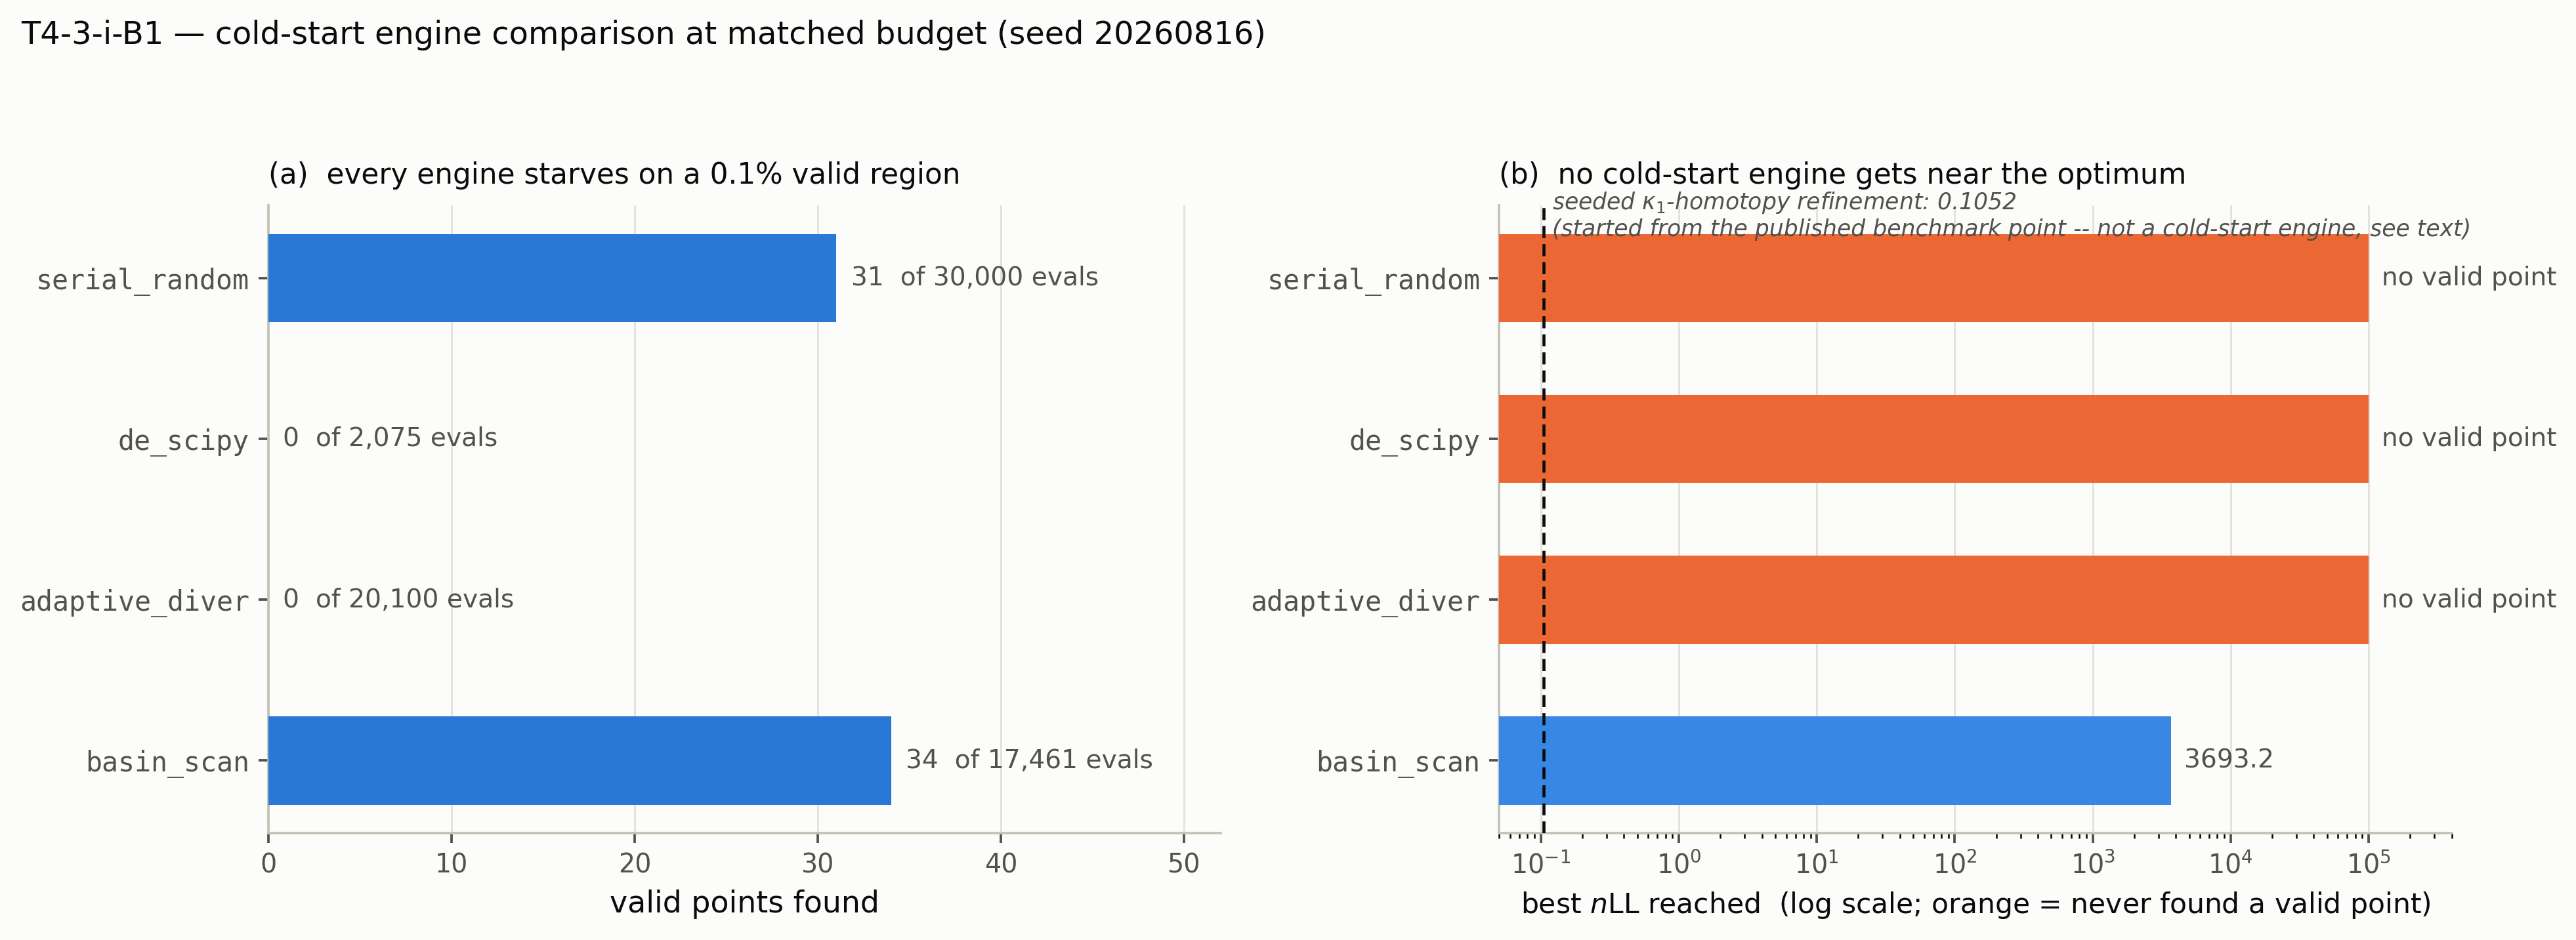

In [7]:
from IPython.display import Image, display
display(Image(filename="figures/t43i_engines.png"))

Panel (b): only the four cold-start engines are drawn as bars. The seeded refinement is a labeled reference line, not a competing bar.

## 6. Best fit: observables and their constraints

Total nLL = 0.105158, at $\kappa_1=-4.00$ (the branch with $R_{\gamma\gamma}>1$; the $\kappa_1>0$ branch tops out at nLL = 0.6377, over six times worse).

In [8]:
pd.DataFrame([{'observable': 'sin^2 theta_12', 'best_fit': 0.307462, 'constraint': 'NuFIT 1sigma [0.300, 0.315]', 'status': 'inside 1sigma'}, {'observable': 'sin^2 theta_13', 'best_fit': 0.0221491, 'constraint': 'NuFIT 1sigma [0.0216, 0.0227]', 'status': 'inside 1sigma'}, {'observable': 'sin^2 theta_23', 'best_fit': 0.470166, 'constraint': 'NuFIT 1sigma [0.460, 0.560]', 'status': 'inside 1sigma'}, {'observable': 'delta_CP [deg]', 'best_fit': -150.391, 'constraint': 'NuFIT profile (bf -150 deg)', 'status': 'at best fit'}, {'observable': 'Delta m^2_21 [eV^2]', 'best_fit': '7.4914e-05', 'constraint': 'NuFIT 1sigma [7.311e-5, 7.674e-5]', 'status': 'inside 1sigma'}, {'observable': 'Delta m^2_3l [eV^2]', 'best_fit': '2.5127e-03', 'constraint': 'NuFIT 1sigma [2.495e-3, 2.530e-3]', 'status': 'inside 1sigma'}, {'observable': 'Sum m_nu [eV]', 'best_fit': 0.0587818, 'constraint': '< 0.12', 'status': 'satisfied'}, {'observable': 'R_gammagamma', 'best_fit': 1.03558, 'constraint': '1.0883 +/- 0.0924', 'status': '0.57 sigma low'}, {'observable': 'BR(mu -> e gamma)', 'best_fit': '1.089e-13', 'constraint': '< 1.5e-13 (MEG II)', 'status': 'satisfied'}, {'observable': 'm1 [eV]', 'best_fit': 0, 'constraint': '--', 'status': 'rank-2 => massless'}, {'observable': 'm2 [eV]', 'best_fit': 0.0086553, 'constraint': '--', 'status': 'prediction'}, {'observable': 'm3 [eV]', 'best_fit': 0.0501265, 'constraint': '--', 'status': 'prediction'}])[['observable', 'best_fit', 'constraint', 'status']]

,observable,best_fit,constraint,status
0,sin^2 theta_12,0.307462,"NuFIT 1sigma [0.300, 0.315]",inside 1sigma
1,sin^2 theta_13,0.022149,"NuFIT 1sigma [0.0216, 0.0227]",inside 1sigma
2,sin^2 theta_23,0.470166,"NuFIT 1sigma [0.460, 0.560]",inside 1sigma
3,delta_CP [deg],-150.391,NuFIT profile (bf -150 deg),at best fit
4,Delta m^2_21 [eV^2],7.4914e-05,"NuFIT 1sigma [7.311e-5, 7.674e-5]",inside 1sigma
5,Delta m^2_3l [eV^2],2.5127e-03,"NuFIT 1sigma [2.495e-3, 2.530e-3]",inside 1sigma
6,Sum m_nu [eV],0.058782,< 0.12,satisfied
7,R_gammagamma,1.03558,1.0883 +/- 0.0924,0.57 sigma low
8,BR(mu -> e gamma),1.089e-13,< 1.5e-13 (MEG II),satisfied
9,m1 [eV],0,--,rank-2 => massless


Not included in this fit (they would need micrOMEGAs/CalcHEP or external one-loop functions not shipped with this benchmark): relic density $\Omega h^2$, spin-independent direct-detection cross section, oblique $S$ and $T$, three-body cLFV, and $\mu$-$e$ conversion.

## 7. Figures

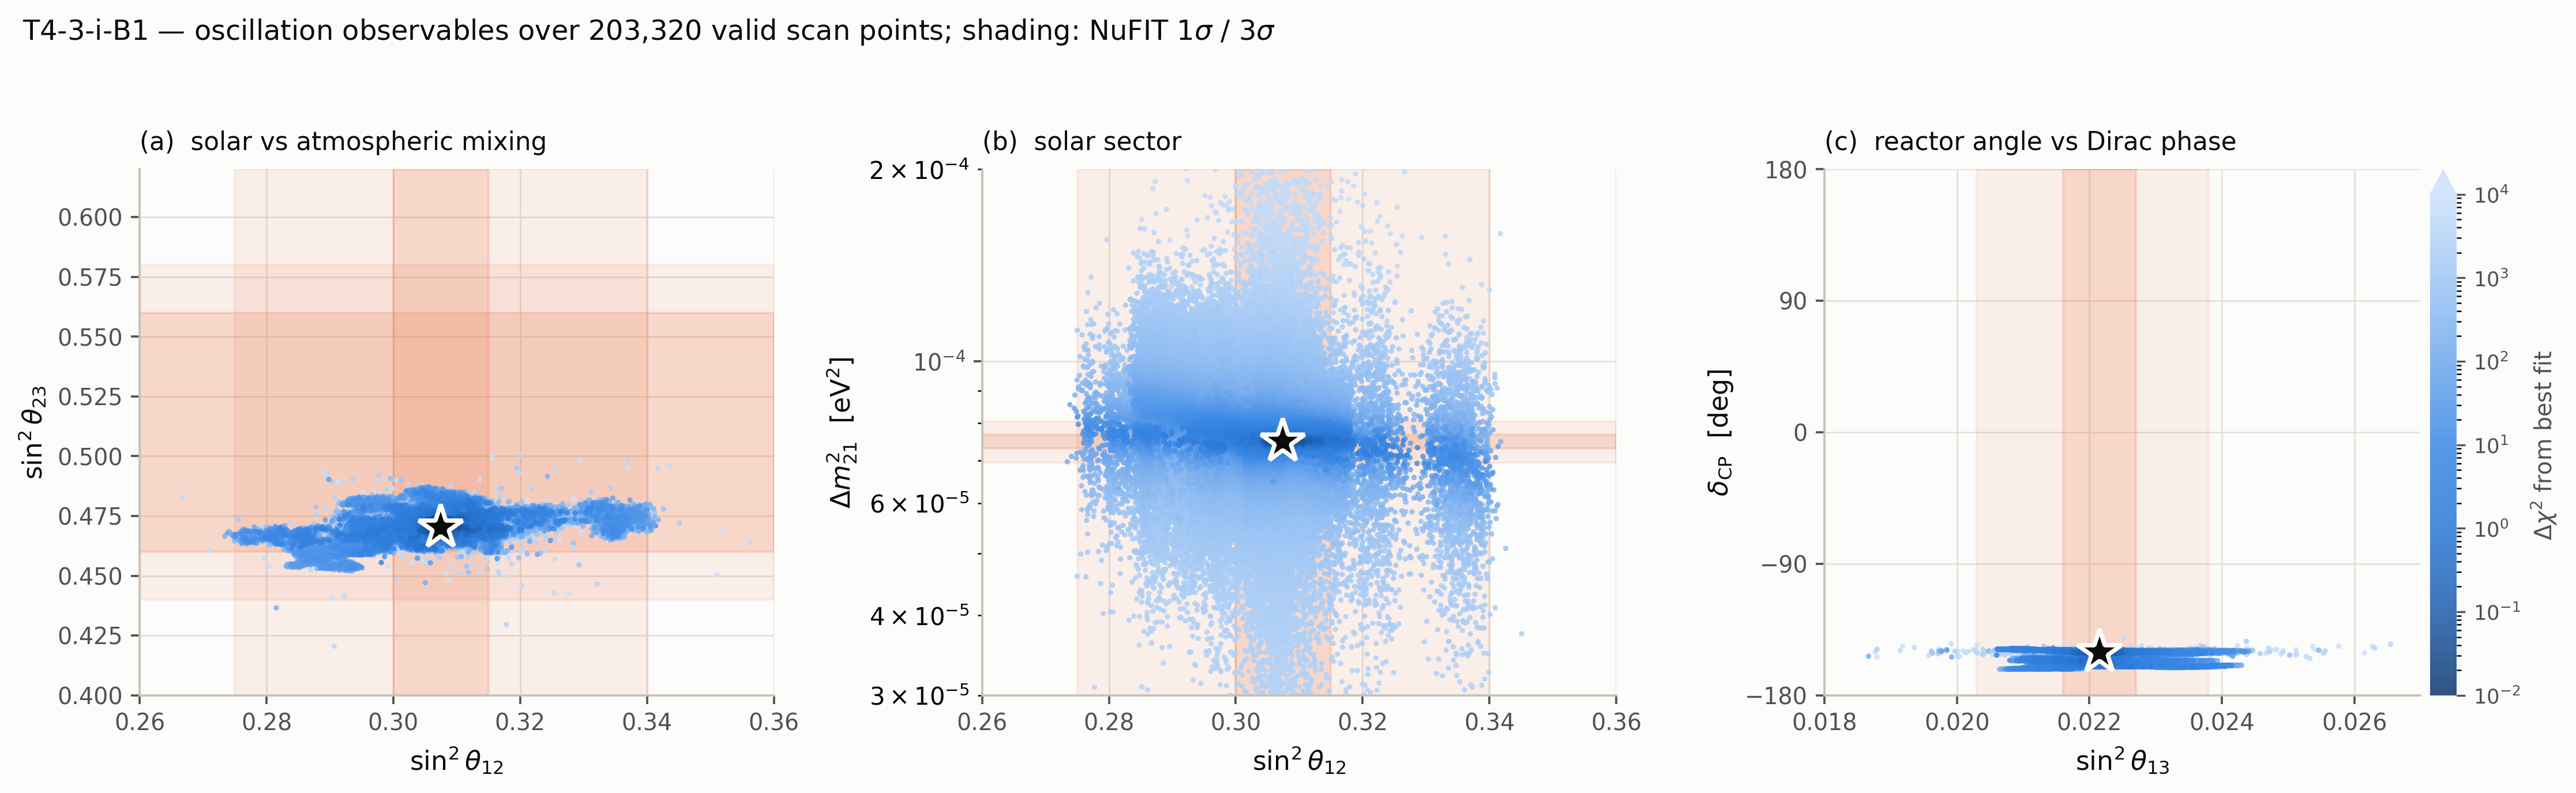

In [9]:
from IPython.display import Image, display
display(Image(filename="figures/t43i_oscillations.png"))

Oscillation observables against the NuFIT 1sigma/3sigma bands.

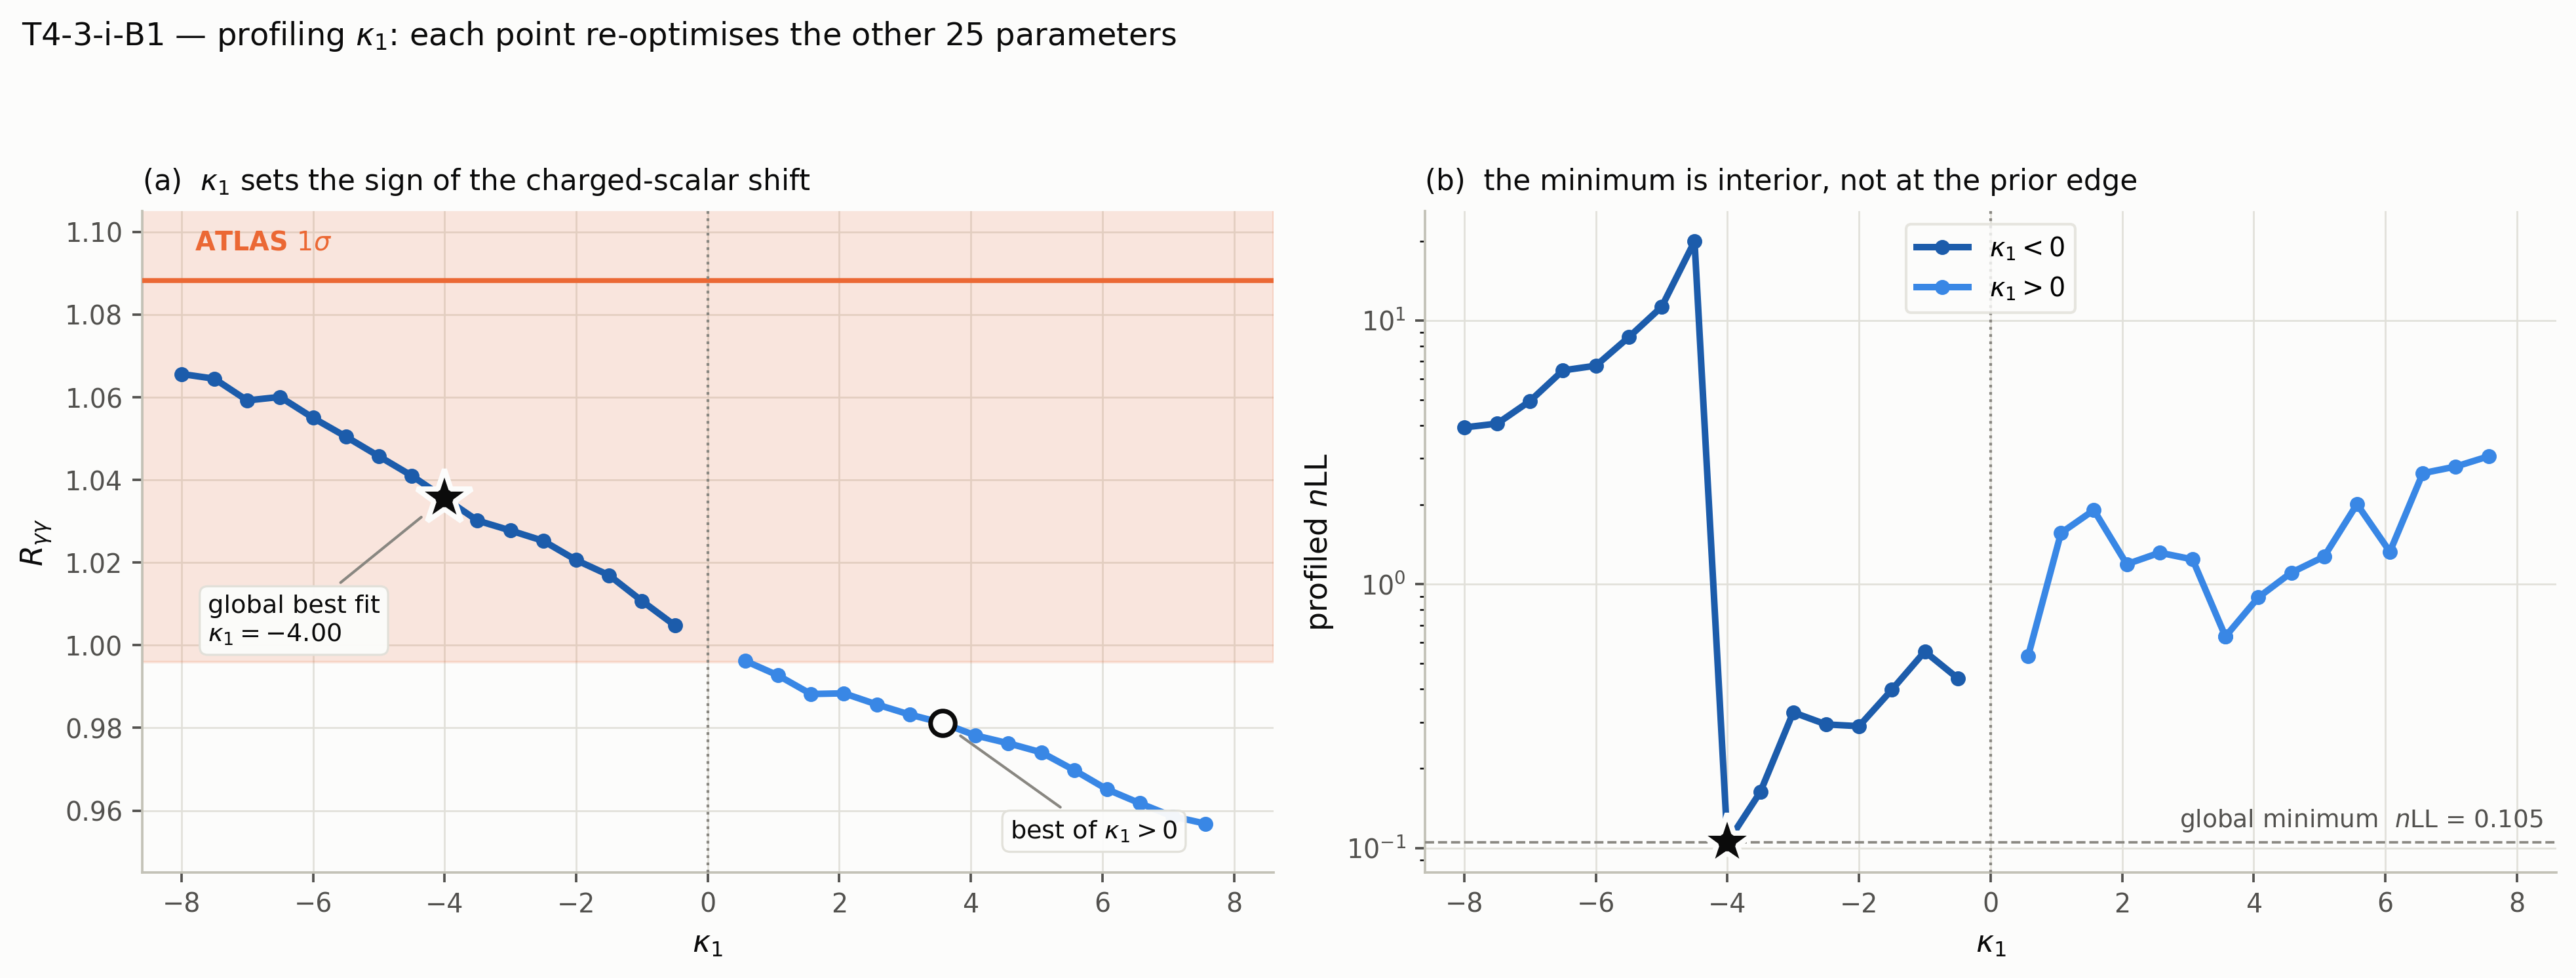

In [10]:
from IPython.display import Image, display
display(Image(filename="figures/t43i_branches.png"))

The two disjoint $\kappa_1$ branches, from a genuine profile-likelihood scan (33 grid points, the other 25 parameters re-optimized at each one) -- not a naive Metropolis cloud, which never moves $\kappa_1$ off two frozen values because it sits directly behind the boundedness-from-below validity wall.

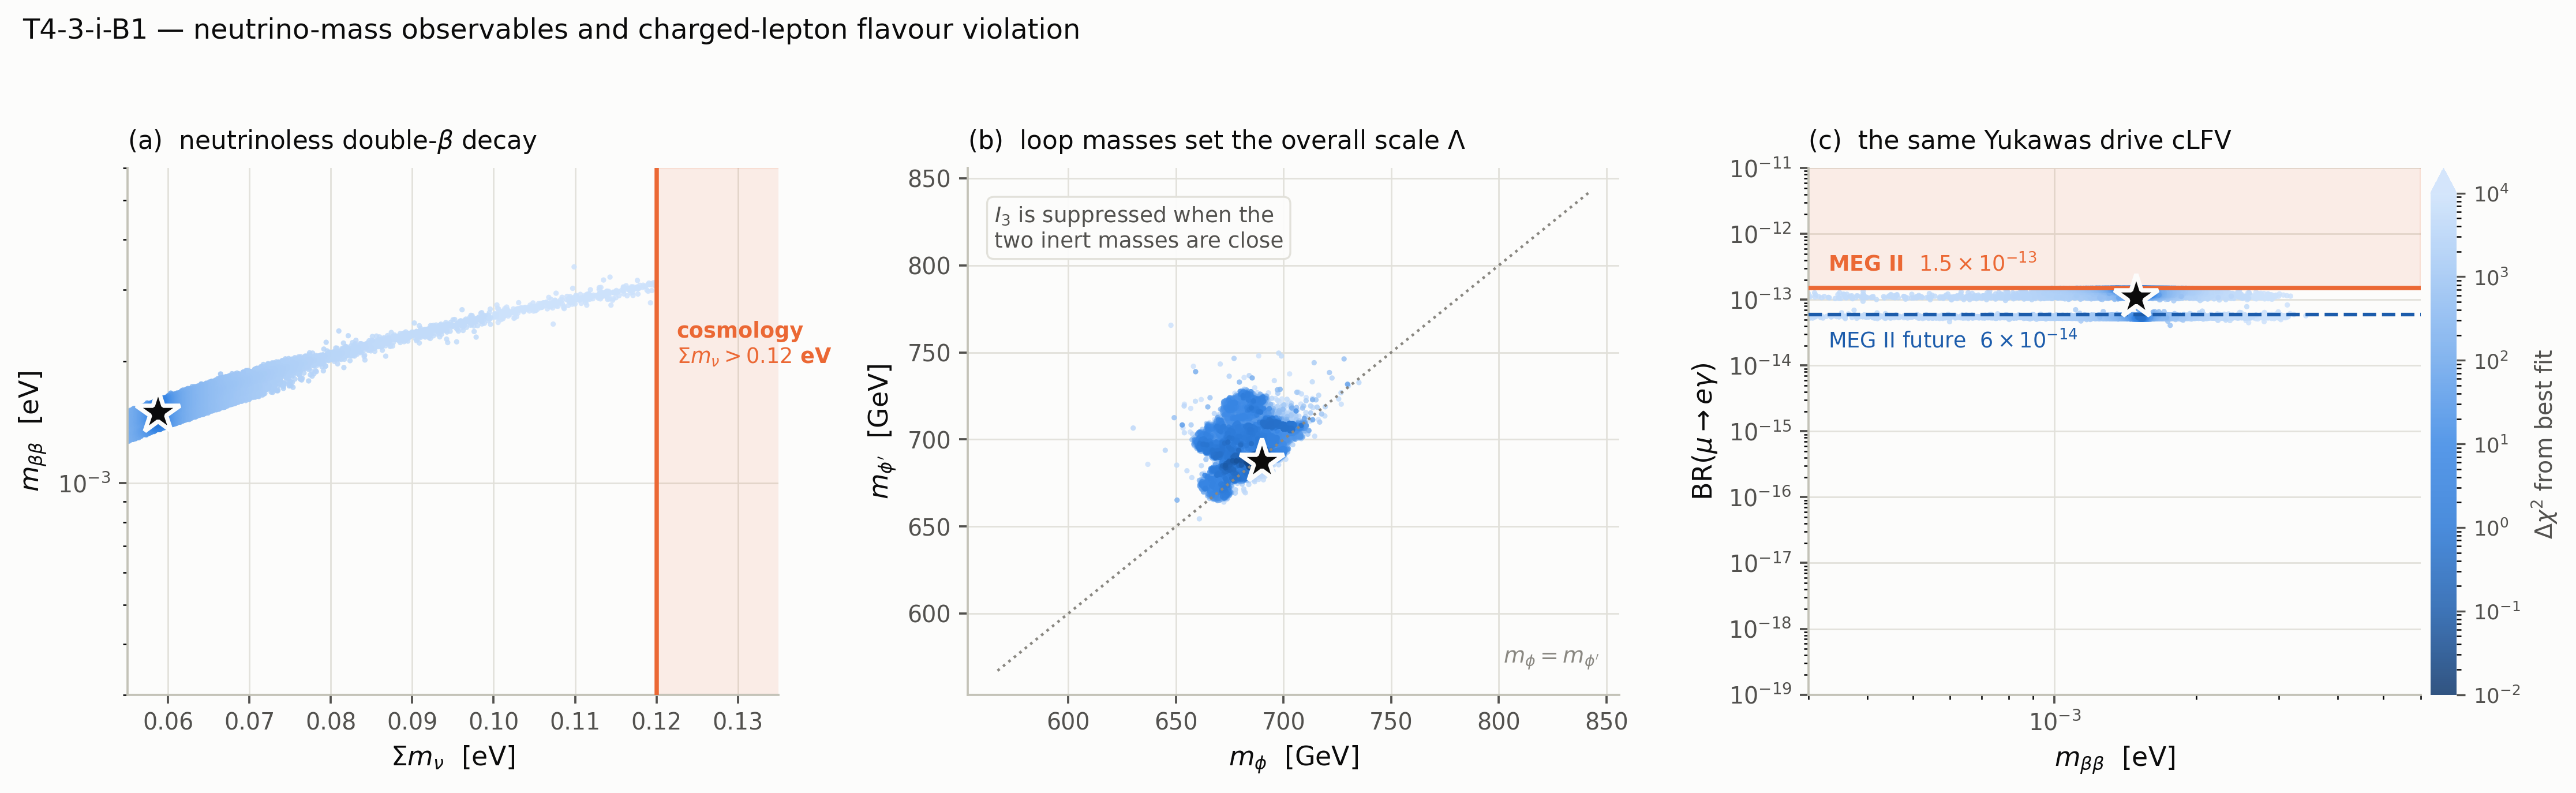

In [11]:
from IPython.display import Image, display
display(Image(filename="figures/t43i_mass_lfv.png"))

Mass spectrum and lepton-flavour-violation observables at the best fit.

## 8. Caveats

This benchmark shares the framework-level caveats of the other seven (NuFIT tables are normal-ordering only, no RGE running) plus one specific to how its best fit was obtained: it is not directly comparable to a cold-start engine result, and the reduced likelihood used here (oscillations, diphoton, mu->e gamma, neutrino-mass sum) is not the paper's own full likelihood, so the nLL values are not directly comparable to the values quoted in arXiv:2608.12646 either.

## 9. Reproducing the full study

Not executed here. The four cold-start engines use the model's dedicated per-engine YAML files (matching how the study was actually run for this benchmark):

In [ ]:
rows = []
engine_files = {
    "serial_random": "../models/t43i_b1/model_serial_random.yaml",
    "de_scipy": "../models/t43i_b1/model_de_scipy.yaml",
    "adaptive_diver": "../models/t43i_b1/model_adaptive_diver.yaml",
    "basin_scan": "../models/t43i_b1/model_basin_scan.yaml",
}
for engine, path in engine_files.items():
    m = load_model(path)
    m.scan.seed = 20260816
    c = compile_model(m)
    r = run_scan(m, c, run_directory=f"runs/{engine}_matched")
    rows.append({"engine": engine, **r.summary})
pd.DataFrame(rows)

---
BSMScanner: a declarative parameter-scanning framework for BSM physics. See the companion paper for the full seven-benchmark methodology study that motivated this eighth, independent worked example.